In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.DataFrame({
    'Girl level': np.concatenate([[0], np.arange(250, 650, 50), [650, 650], np.arange(700, 800, 50)])
})

df['Power'] = df['Girl level'].apply(lambda x: int(x * 1.4) if x > 650 else x)

df.loc[df['Girl level'] == 650, 'Power'] = [650, int(650 * 1.4)] 
df['Bonus'] = df['Power'].apply(lambda x: 'Yes' if x == int(650 * 1.4) else 'No')

print("DataFrame with duplicate at 650:")
print(df)

DataFrame with duplicate at 650:
    Girl level  Power Bonus
0            0      0    No
1          250    250    No
2          300    300    No
3          350    350    No
4          400    400    No
5          450    450    No
6          500    500    No
7          550    550    No
8          600    600    No
9          650    650    No
10         650    909   Yes
11         700    979    No
12         750   1050    No


Saved as PNG: images/Powerlevel.png


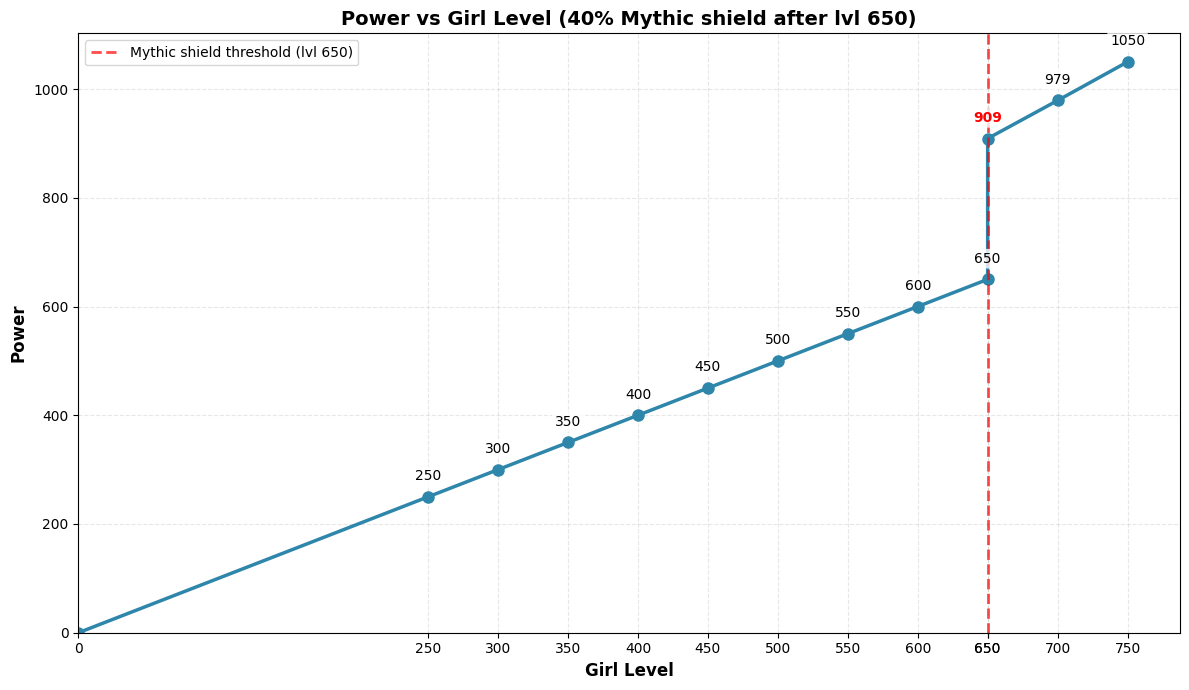

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(df['Girl level'], df['Power'], 'o-', linewidth=2.5, markersize=8, color='#2E86AB')

# Force axes to start at 0,0
ax.set_xlim(0, max(df['Girl level']) * 1.05)  # Start at 0, end at max + 5%
ax.set_ylim(0, max(df['Power']) * 1.05)  # Start at 0, end at max + 5%

# Set x-axis ticks to exact DataFrame values
ax.set_xticks(df['Girl level'])
ax.set_xticklabels(df['Girl level'].astype(int), rotation=45, ha='right')

# Labels and title
ax.set_xlabel('Girl Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Power', fontsize=12, fontweight='bold')
ax.set_title('Power vs Girl Level (40% Mythic shield after lvl 650)', fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add threshold line
ax.axvline(x=650, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mythic shield threshold (lvl 650)')
ax.legend()

# Add value labels on top of each point (skip the point at 0,0)
for i, row in df.iterrows():
    # Skip annotation for the point at (0,0)
    if row['Girl level'] == 0 and row['Power'] == 0:
        continue
    
    if False:
        pass
    # elif row['Girl level'] > 650:
    #     color = 'red'
    #     fontweight = 'bold'
    elif row['Bonus'] == "Yes":
        color = 'red'
        fontweight = 'bold'
    else:
        color = 'black'
        fontweight = 'normal'
    
    ax.annotate(f'{int(row["Power"])}', 
                (row['Girl level'], row['Power']),
                textcoords="offset points", 
                xytext=(0, 12),
                ha='center',
                fontsize=10,
                fontweight=fontweight,
                color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))

# Ensure the plot starts at exactly 0,0
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

plt.tight_layout()


plt.savefig('images/Powerlevel.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved as PNG: images/Powerlevel.png")
